# 🎵 My Spotify Listening Analysis

## Key Findings:
- Total listening time: 1,210 hours
- Top artist: **BTS **(89 hours)
- Peak listening time: 3am-5am (confirmed night owl 🦉)
- Highest listening month: August

In [42]:
from google.colab import files
uploded = files.upload()


Saving StreamingHistory_music_0.json to StreamingHistory_music_0 (1).json
Saving StreamingHistory_music_1.json to StreamingHistory_music_1 (1).json
Saving StreamingHistory_music_2.json to StreamingHistory_music_2 (1).json


In [43]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
import pandas as pd
import json

df0 = pd.read_json('StreamingHistory_music_0.json')
df1 = pd.read_json('StreamingHistory_music_1.json')
df2 = pd.read_json('StreamingHistory_music_2.json')

df = pd.concat([df0, df1, df2], ignore_index=True)

print(df.shape)
df.head()




(29535, 4)


,endTime,artistName,trackName,msPlayed
0,2025-06-06 01:55,Charlie Puth,Dangerously,2995
1,2025-06-06 01:58,J.Tajor,Like I Do,149142
2,2025-06-06 02:03,Ricky Montgomery,Line Without a Hook,249586
3,2025-06-06 02:10,Jin,Abyss,155108
4,2025-06-06 03:03,ROSÉ,Gone,126916


In [16]:
df['minutes_played'] = df['msPlayed'] / 60000
df_clean = df[df['minutes_played'] > 0.5 ]

print("Before cleaning: ", len(df))
print("After cleaning: ", len(df_clean))

Before cleaning:  29535
After cleaning:  23664


In [17]:
top_artists = df_clean['artistName'].value_counts().head(10)
print(top_artists)

artistName
BTS              1607
Taylor Swift     1457
Justin Bieber     511
Ariana Grande     394
LAUV              378
One Direction     273
10CM              258
Troye Sivan       256
V                 255
Jung Kook         214
Name: count, dtype: int64


In [18]:
top_songs = df_clean['trackName'].value_counts().head(10)
print(top_songs)

trackName
I Like Me Better                   89
Eenie Meenie                       88
midsummer pipe dream               85
Cruel Summer                       77
Side To Side                       74
Ribs                               71
输入法打可爱按第五 - 纯享版                    71
I Can Do It With a Broken Heart    71
Lover                              70
Everyday                           68
Name: count, dtype: int64


## 1. My Top 10 Most Played Artists
BTS dominates my listening history with over 1,600 plays,
followed closely by Taylor Swift. Both artists account for
nearly 30% of my total listening history.

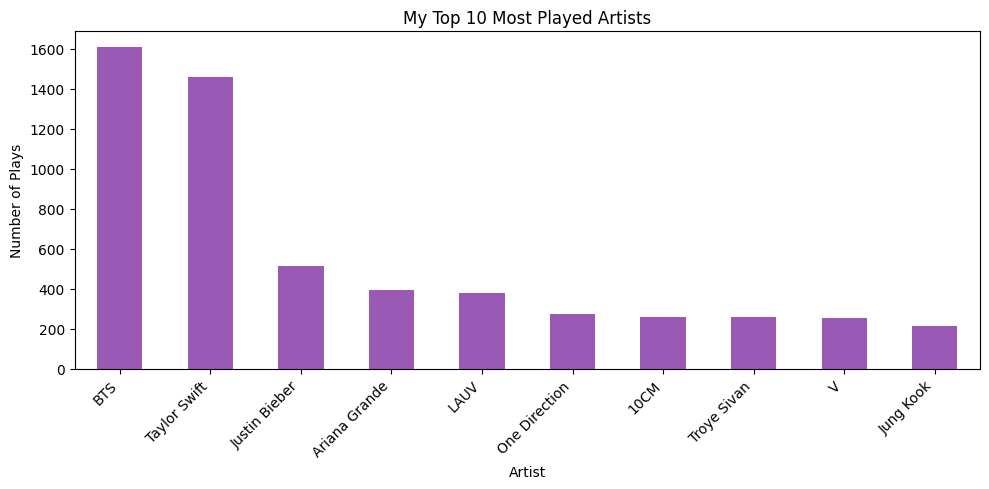

In [24]:
import matplotlib.pyplot as plt

top_artists.plot(kind = 'bar', color='#9B59B6', figsize=(10,5))
plt.title('My Top 10 Most Played Artists')
plt.xlabel('Artist')
plt.ylabel('Number of Plays')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. My Top 10 Most Played Songs
"I Like Me Better" by LAUV is my most replayed song with 89 plays,
followed by "Eenie Meenie" at 88 plays.

Total hours listened: 1210.2


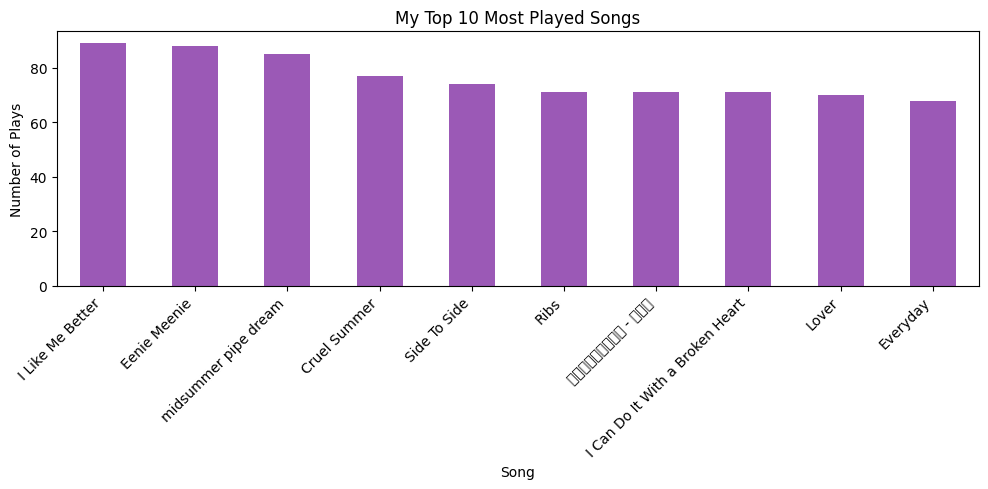

In [45]:
total_hours = df_clean['minutes_played'].sum()/60
print(f"Total hours listened: {round(total_hours, 1)}")

top_songs.plot(kind='bar', color='#9B59B6', figsize=(10,5))
plt.title('My Top 10 Most Played Songs')
plt.xlabel('Song')
plt.ylabel('Number of Plays')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
df_clean['endTime'] = pd.to_datetime(df_clean['endTime'])
df_clean['year'] = df_clean['endTime'].dt.year

yearly = df_clean.groupby('year')['minutes_played'].sum() / 60
print(yearly.round(1))

year
2025    742.7
2026    467.5
Name: minutes_played, dtype: float64


## 3. Listening Habits by Time of Day
I listen to music most between 3am-5am, revealing strong
night owl tendencies. Listening drops significantly in early morning hours.

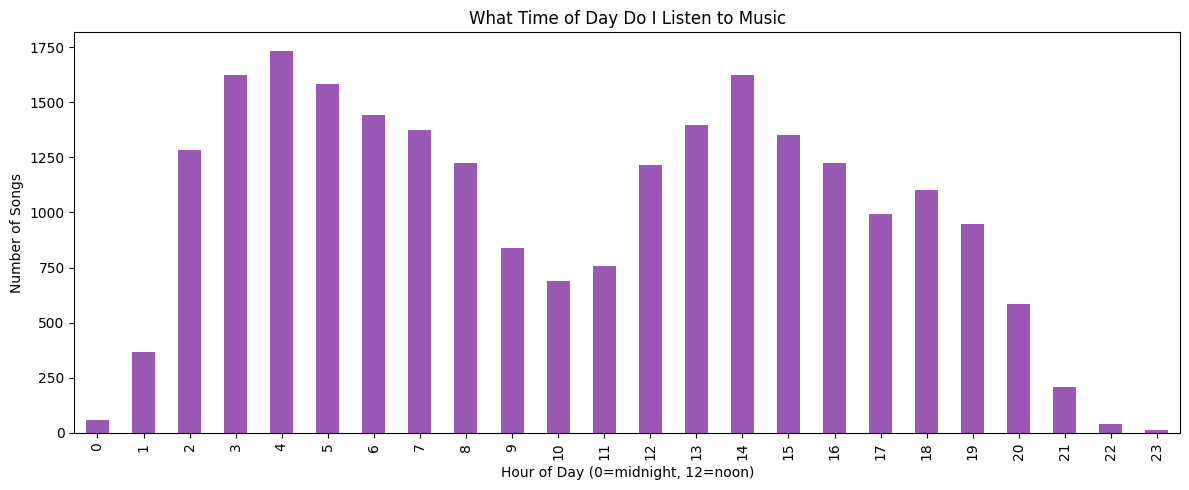

In [46]:
df_clean['hour'] = df_clean['endTime'].dt.hour

hourly = df_clean.groupby('hour')['trackName'].count()

hourly.plot(kind='bar', color='#9B59B6', figsize=(12,5))
plt.title('What Time of Day Do I Listen to Music')
plt.xlabel('Hour of Day (0=midnight, 12=noon)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

## 4. Monthly Listening Patterns
August was my peak listening month, while June-July
showed the lowest activity.

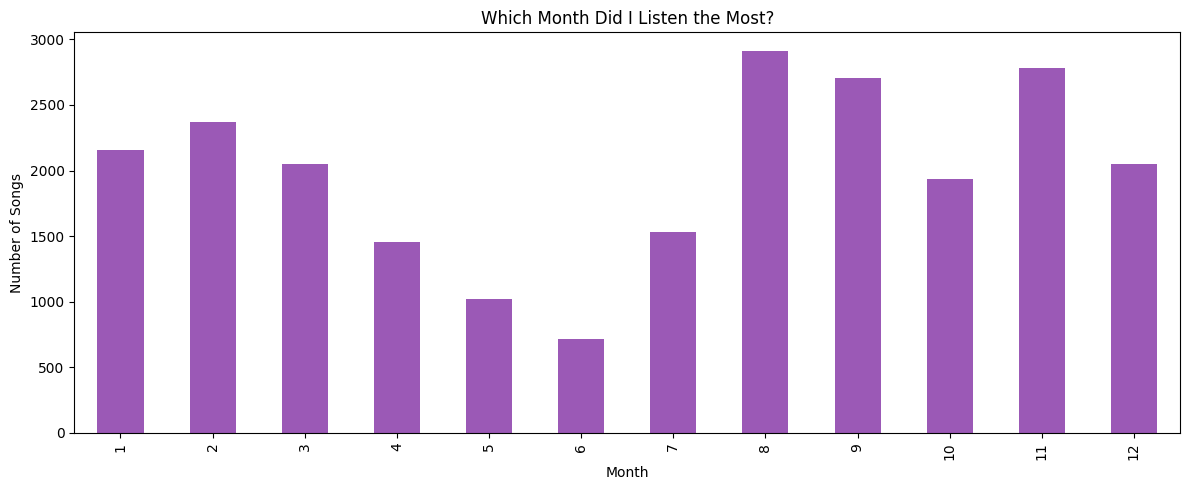

In [47]:
df_clean['month'] = df_clean['endTime'].dt.month

monthly = df_clean.groupby('month')['trackName'].count()

monthly.plot(kind='bar', color='#9B59B6', figsize=(12,5))
plt.title('Which Month Did I Listen the Most?')
plt.xlabel('Month')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

## 5. Top Artists by Total Hours
When measured by actual hours, BTS (89hrs) and Taylor Swift (84hrs)
are nearly equal, showing similar dedication to both artists.

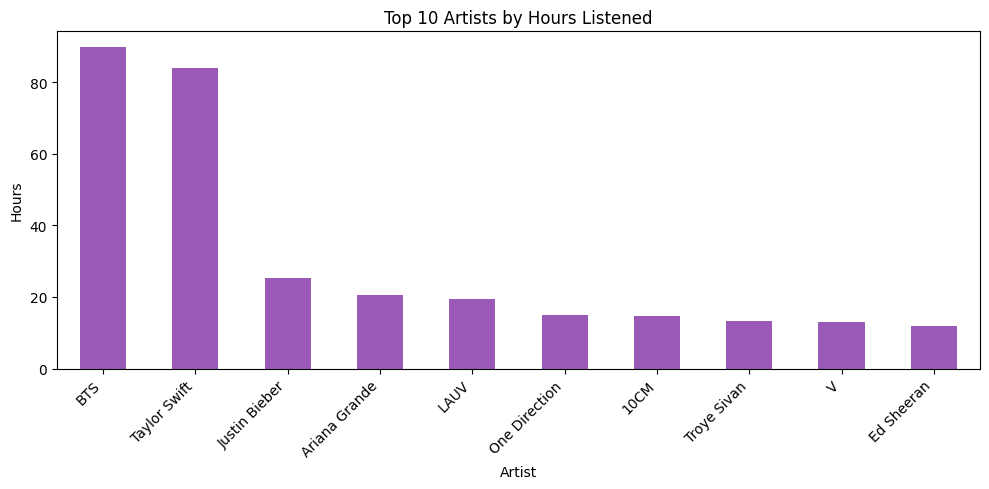

In [48]:
artist_hours = df_clean.groupby('artistName')['minutes_played'].sum().sort_values(ascending=False).head(10) / 60

artist_hours.plot(kind='bar', color='#9B59B6', figsize=(10,5))
plt.title('Top 10 Artists by Hours Listened')
plt.xlabel('Artist')
plt.ylabel('Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()